# MAD 移動均線距離策略（Moving Average Distance）

## 策略簡介

本策略基於 Avramov、Kaplanski 與 Subrahmanyam 的學術研究：
**《Moving Average Distance as a Predictor of Equity Returns》**

研究發現，**短期均線與長期均線的距離比率（MRAT）** 能有效預測股票報酬。
當短期均線高於長期均線且偏離程度超過橫截面標準差時，股票往往有正向超額報酬。

### 行為財務學基礎：錨定效應

- **錨定偏誤**：投資人傾向以長期均線（MA200）作為「公平價值」錨點
- 當短期均線大幅突破錨點，代表市場情緒積極且動能強勁
- 動能研究顯示，**高 MRAT 股票在接下來的 1–12 個月表現持續優異**

### 核心指標：MRAT（Moving Average Ratio）

```
MRAT = MA(21) / MA(200)
```

- **MA(21)**：近 21 日收盤價平均（約 1 個月）
- **MA(200)**：近 200 日收盤價平均（約 1 年）
- **MRAT > 1**：短均線在長均線上方（多頭排列）
- **MRAT 越高**：動能越強，與均線偏離越大

### 選股條件（月底執行，次日換倉）

每月月底，同時滿足以下兩個條件方可入選：

1. **MRAT 百分位 > 90%**：該股 MRAT 在全市場前 10%
2. **MRAT > 1 + σ**：MRAT 超過（1 + 全市場橫截面標準差）

### 回測設定

| 項目 | 設定值 |
|------|--------|
| 投資標的 | 台灣證券交易所上市普通股 |
| 回測期間 | 2020-01-02 ～ 2024-06-30 |
| 基準指數 | 台灣加權報酬指數（IR0001）|
| 再平衡頻率 | 每月月底 |
| 初始資金 | 1,000 萬元 |
| 持股權重 | 等權重 |

---


## 1. 環境設定與套件載入

**注意事項**：
- 本策略使用 `python-dotenv` 載入 TEJ API 金鑰，請在根目錄建立 `.env`：
  ```
  TEJAPI_KEY=your_api_key_here
  TEJAPI_BASE=https://api.tej.com.tw
  ```


In [2]:
import os
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from dotenv import load_dotenv
load_dotenv()

# TEJ API 設定
import tejapi
tejapi.ApiConfig.api_key  = os.getenv('TEJAPI_KEY')
tejapi.ApiConfig.api_base = os.getenv('TEJAPI_BASE')
os.environ['TEJAPI_KEY']  = os.getenv('TEJAPI_KEY')
os.environ['TEJAPI_BASE'] = os.getenv('TEJAPI_BASE')

warnings.filterwarnings('ignore')

# 載入中文字體
from matplotlib import font_manager
font_path = 'SourceHanSansTC-Regular.otf'
font_manager.fontManager.addfont(font_path)
prop      = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
plt.rcParams['font.family']        = font_name
plt.rcParams['axes.unicode_minus'] = False

print(f"已成功載入字體: {font_name}")


已成功載入字體: Source Han Sans TC


## 2. 策略參數設定


In [3]:
# ── 資料區間 ──────────────────────────────────────────────────────────────────
DATA_START     = '2019-01-01'   # 價格資料起始（供 MA200 暖機，需早於回測至少 1 年）
BACKTEST_START = '2019-12-29'   # Zipline 回測開始（含首次月底換倉訊號）
END_DATE       = '2024-06-30'   # 回測結束

# ── 均線參數 ──────────────────────────────────────────────────────────────────
MA_SHORT       = 21             # 短期均線天數（論文使用 21 日）
MA_LONG        = 200            # 長期均線天數（論文使用 200 日）

# ── 選股參數 ──────────────────────────────────────────────────────────────────
TOP_DECILE     = 0.90           # MRAT 前 10% 分位門檻

# ── 資金設定 ──────────────────────────────────────────────────────────────────
CAPITAL_BASE   = 1e7            # 初始資金 1,000 萬元

# ── 快取設定（避免重複拉資料）─────────────────────────────────────────────────
PRICE_CACHE    = 'mad_price_pivot.parquet'
HIGH_CACHE     = 'mad_high_pivot.parquet'
LOW_CACHE      = 'mad_low_pivot.parquet'

print("策略參數設定完成")
print(f"  資料期間：{DATA_START} ~ {END_DATE}")
print(f"  回測期間：{BACKTEST_START} ~ {END_DATE}")
print(f"  均線設定：MA({MA_SHORT}) / MA({MA_LONG})")
print(f"  選股門檻：MRAT 前 {int((1 - TOP_DECILE) * 100)}%  且  MRAT > 1 + σ")
print(f"  初始資金：{CAPITAL_BASE:,.0f} 元")


策略參數設定完成
  資料期間：2019-01-01 ~ 2024-06-30
  回測期間：2019-12-29 ~ 2024-06-30
  均線設定：MA(21) / MA(200)
  選股門檻：MRAT 前 9%  且  MRAT > 1 + σ
  初始資金：10,000,000 元


## 3. 股票池設定

從台灣證券交易所（TSE）取得所有上市普通股作為選股範圍。


In [4]:
from zipline.sources.TEJ_Api_Data import get_universe

pool = get_universe(
    start   = pd.Timestamp(BACKTEST_START, tz='utc'),
    end     = pd.Timestamp(END_DATE,       tz='utc'),
    mkt_bd_e = ['TSE'],
    stktp_e  = 'Common Stock'
)

print(f"股票池總數: {len(pool)} 檔")


Currently used TEJ API key call quota 1080/100000 (1.08%)
Currently used TEJ API key data quota 110414478/10000000 (1104.14%)
股票池總數: 939 檔


## 4. 收盤價資料獲取

取得全市場收盤價，建立日期 × 股票的 pivot 表。
首次執行會從 TEJ API 下載資料，之後讀取本地快取（Parquet）以節省 API Quota。


In [5]:
import TejToolAPI

all_caches_exist = (
    os.path.exists(PRICE_CACHE) and
    os.path.exists(HIGH_CACHE)  and
    os.path.exists(LOW_CACHE)
)

if all_caches_exist:
    print(f"讀取本地快取：{PRICE_CACHE} / {HIGH_CACHE} / {LOW_CACHE}")
    price_pivot = pd.read_parquet(PRICE_CACHE)
    high_pivot  = pd.read_parquet(HIGH_CACHE)
    low_pivot   = pd.read_parquet(LOW_CACHE)
    for df in (price_pivot, high_pivot, low_pivot):
        df.index = pd.to_datetime(df.index)
else:
    print("快取不完整，開始從 TEJ API 抓取 OHLC 資料...")

    price_data = TejToolAPI.get_history_data(
        ticker              = pool,
        start               = DATA_START,
        end                 = END_DATE,
        fin_type            = ['Q'],
        columns             = ['close_d', 'high_d', 'low_d'],
        transfer_to_chinese = True,
        include_self_acc    = 'Y'
    )

    price_data['日期'] = pd.to_datetime(price_data['日期'])

    def _pivot(col):
        return price_data.pivot_table(
            index='日期', columns='股票代碼', values=col
        )

    price_pivot = _pivot('收盤價')
    high_pivot  = _pivot('最高價')
    low_pivot   = _pivot('最低價')

    price_pivot.to_parquet(PRICE_CACHE)
    high_pivot.to_parquet(HIGH_CACHE)
    low_pivot.to_parquet(LOW_CACHE)
    print(f"已儲存快取：{PRICE_CACHE} / {HIGH_CACHE} / {LOW_CACHE}")

print(f"\n價格矩陣大小：{price_pivot.shape[0]} 天 × {price_pivot.shape[1]} 檔股票")
print(f"日期範圍：{price_pivot.index[0].date()} ~ {price_pivot.index[-1].date()}")


讀取本地快取：mad_price_pivot.parquet / mad_high_pivot.parquet / mad_low_pivot.parquet

價格矩陣大小：1639 天 × 970 檔股票
日期範圍：2019-01-02 ~ 2025-09-30


## 5. MRAT 計算與選股訊號

### 5a. 計算雙均線與 MRAT

利用 pandas `rolling` 向量化計算，一次對全市場所有股票同步計算。


In [6]:
# 向量化計算雙均線
ma_short = price_pivot.rolling(window=MA_SHORT, min_periods=MA_SHORT).mean()
ma_long  = price_pivot.rolling(window=MA_LONG,  min_periods=MA_LONG).mean()

# MRAT = MA(21) / MA(200)
mrat = ma_short / ma_long

# 基本統計（對照論文 Table 1 - 全市場 MRAT 均值約 1.047）
mrat_all = mrat.stack().dropna()
print(f"MRAT 矩陣大小：{mrat.shape}")
print(f"全市場 MRAT 均值：{mrat_all.mean():.4f}（論文期待值約 1.047）")
print(f"全市場 MRAT 標準差：{mrat_all.std():.4f}")
print(f"MRAT > 1 的比例：{(mrat_all > 1).mean()*100:.1f}%（多頭排列股票佔比）")


MRAT 矩陣大小：(1639, 970)
全市場 MRAT 均值：1.0315（論文期待值約 1.047）
全市場 MRAT 標準差：0.1907
MRAT > 1 的比例：50.2%（多頭排列股票佔比）


### 5b. 計算月底再平衡日期

使用 TEJ 交易日曆（`TWN/TRADEDAY_TWSE`）取得每月最後交易日，比從個股股價推算更穩健。


In [7]:
# 取得台灣證交所交易日曆
trade_days = tejapi.get(
    'TWN/TRADEDAY_TWSE',
    zdate        = {'gte': BACKTEST_START, 'lte': END_DATE},
    tradeday_cno = {'ne': 0},     # 只取交易日
    paginate     = True
)

trade_days['zdate'] = pd.to_datetime(trade_days['zdate'])
trade_days['year']  = trade_days['zdate'].dt.year
trade_days['month'] = trade_days['zdate'].dt.month

# 取每月最後一個交易日
monthly_last = (
    trade_days
    .groupby(['year', 'month'])['zdate']
    .max()
    .reset_index()
    .sort_values('zdate')
)

# 轉為 date 集合（供 handle_data 查找）
rebalance_dates      = set(d.date() for d in monthly_last['zdate'])
rebalance_dates_list = sorted(rebalance_dates)

print(f"月度再平衡日期：共 {len(rebalance_dates)} 個")
print(f"前 6 個：{rebalance_dates_list[:6]}")
print(f"最後 3 個：{rebalance_dates_list[-3:]}")


月度再平衡日期：共 55 個
前 6 個：[datetime.date(2019, 12, 31), datetime.date(2020, 1, 31), datetime.date(2020, 2, 27), datetime.date(2020, 3, 31), datetime.date(2020, 4, 30), datetime.date(2020, 5, 29)]
最後 3 個：[datetime.date(2024, 4, 30), datetime.date(2024, 5, 31), datetime.date(2024, 6, 28)]


### 5c. 選股函數與月度訊號字典

定義 `compute_mad_signal()` 函數，對每個再平衡日期套用基礎 MAD 條件後，
再疊加三個純 price-action 進場過濾，批次產生 `signal_dict`。

#### Price-action 進場過濾邏輯（僅用 OHLC，無任何指標）

| 過濾條件 | 計算方式 | 行為邏輯 |
|----------|----------|----------|
| **F1 動能有效性** | `Close / max(High, 近20日) > 0.88` | MRAT 反映歷史累積距離，可能已滯後。若股價已從近期高點回落 >12%，動能已在衰減；此過濾排除「殭屍動能」——MRAT 仍高但走勢已轉弱的股票 |
| **F2 更高低點結構** | `min(Close, 近10日) > min(Close, 第11~20日)` | 健康上升趨勢的標誌是買方在愈來愈高的位置護盤。若近期低點開始下移（即使高點還在），代表分配盤正在進行；此過濾排除高MRAT但低點已跌破的潛在反轉標的 |
| **F3 振幅收窄壓縮** | `mean(High-Low, 近5日) < mean(High-Low, 第6~15日)` | 強勢後的健康整理，日振幅應收窄（供給枯竭、蓄勢待發）。末升段或頭部區域則出現振幅擴張（多空激烈對抗）；此過濾排除拋物線加速或頭部震盪的超漲標的 |

> **前視偏誤防範**：所有過濾條件均只使用月底當日及之前的 OHLC 資料，不存在未來資料洩漏。


In [8]:
def compute_mad_signal(rebal_date, mrat_pivot, high_pivot, low_pivot,
                       price_pivot, top_decile=TOP_DECILE):
    """
    MAD 選股函數：在指定再平衡日計算入選股票清單

    基礎條件（同時滿足）：
      1. MRAT percentile rank > top_decile（前 10%）
      2. MRAT > 1 + σ（橫截面標準差）

    Price-action 進場過濾（同時滿足，僅用 OHLC，無指標）：
      F1. 收盤 / 近 20 日最高價 > 0.88          → 動能仍在，非高點回落
      F2. 近 10 日最低收盤 > 前 10 日最低收盤    → 更高低點結構完整
      F3. 近 5 日平均振幅 < 前 10 日平均振幅     → 上漲後壓縮，非末升擴張

    參數：
      rebal_date  : 再平衡日期（date 物件）
      mrat_pivot  : MRAT 矩陣（index=日期，columns=股票代碼）
      high_pivot  : 日最高價矩陣
      low_pivot   : 日最低價矩陣
      price_pivot : 日收盤價矩陣
      top_decile  : 分位數門檻，預設 0.90

    回傳：
      入選股票代碼列表（list of str）
    """
    ts = pd.Timestamp(rebal_date)

    available = mrat_pivot.index[mrat_pivot.index <= ts]
    if len(available) == 0:
        return []

    last_ts = available[-1]
    section = mrat_pivot.loc[last_ts].dropna()

    if len(section) < 50:
        return []

    sigma    = section.std()
    pct_rank = section.rank(pct=True)

    # ── 基礎 MAD 條件 ─────────────────────────────────────────────────────────
    base_mask  = (pct_rank > top_decile) & (section > (1.0 + sigma))
    candidates = section[base_mask].index.tolist()

    if not candidates:
        return []

    # ── 取近 20 交易日視窗 ────────────────────────────────────────────────────
    avail_idx = price_pivot.index[price_pivot.index <= last_ts]
    if len(avail_idx) < 20:
        return candidates   # 歷史不足，略過 price action 篩選

    # 只保留三張表都有的候選股
    shared = [c for c in candidates
              if c in high_pivot.columns and c in low_pivot.columns
              and c in price_pivot.columns]
    if not shared:
        return []

    close_20 = price_pivot.loc[avail_idx[-20:], shared]
    high_20  = high_pivot.loc[avail_idx[-20:], shared]
    low_20   = low_pivot.loc[avail_idx[-20:], shared]
    range_20 = (high_20 - low_20).values        # shape: (20, n)

    # ── F1：收盤 / 近 20 日最高價 > 0.88 ─────────────────────────────────────
    f1 = (close_20.iloc[-1] / high_20.max()) > 0.88

    # ── F2：近 10 日最低收盤 > 前 10 日（第 11~20 日）最低收盤 ───────────────
    f2 = close_20.iloc[-10:].min() > close_20.iloc[:10].min()

    # ── F3：近 5 日平均振幅 < 前 10 日（第 6~15 日）平均振幅 ─────────────────
    avg_recent = pd.Series(range_20[-5:].mean(axis=0),   index=shared)
    avg_prior  = pd.Series(range_20[-15:-5].mean(axis=0), index=shared)
    f3 = avg_recent < avg_prior

    combined = f1 & f2 & f3
    return combined[combined].index.tolist()


# ── 批次計算所有月底的選股結果 ────────────────────────────────────────────────
signal_dict = {}
for d in rebalance_dates_list:
    signal_dict[d] = compute_mad_signal(
        d, mrat, high_pivot, low_pivot, price_pivot
    )

# ── 統計選股結果 ──────────────────────────────────────────────────────────────
counts      = [len(v) for v in signal_dict.values()]
empty_count = sum(1 for c in counts if c == 0)

print(f"選股統計（共 {len(signal_dict)} 個再平衡日）：")
print(f"  平均選股數：{np.mean(counts):.1f} 檔")
print(f"  最多：{max(counts)} 檔，最少：{min(counts)} 檔")
print(f"  空倉月份（0 檔）：{empty_count} 個月")

# ── 顯示前 5 期選股結果 ───────────────────────────────────────────────────────
print("\n前 5 期選股預覽：")
for d in rebalance_dates_list[:5]:
    tickers = signal_dict[d]
    preview = tickers[:5]
    print(f"  {d} → {len(tickers):3d} 檔：{preview}{'...' if len(tickers) > 5 else ''}")


選股統計（共 55 個再平衡日）：
  平均選股數：22.0 檔
  最多：42 檔，最少：3 檔
  空倉月份（0 檔）：0 個月

前 5 期選股預覽：
  2019-12-31 →  36 檔：['1315', '1321', '1339', '2207', '2303']...
  2020-01-31 →   8 檔：['1435', '1732', '2312', '2429', '2478']...
  2020-02-27 →  10 檔：['2207', '2491', '2705', '6165', '6166']...
  2020-03-31 →   3 檔：['1325', '4736', '6166']
  2020-04-30 →  15 檔：['2102', '2363', '2478', '3042', '3383']...


## 6. Zipline 資料匯入（simple_ingest）

只匯入曾出現在 `signal_dict` 中的股票與基準指數，節省 API Quota。


In [9]:
from zipline.data.run_ingest import simple_ingest

# 收集所有曾入選的股票代碼
all_selected = set()
for tickers in signal_dict.values():
    all_selected.update(tickers)
all_selected.add('IR0001')      # 加入基準指數

ingest_pool = list(all_selected)
print(f"需要 Ingest 的標的：{len(ingest_pool)} 個（含 IR0001）")
print("開始匯入 Zipline 資料...")

simple_ingest(
    name       = 'tquant',
    tickers    = ingest_pool,
    start_date = BACKTEST_START.replace('-', ''),
    end_date   = END_DATE.replace('-', '')
)

print("資料匯入完成！")


需要 Ingest 的標的：506 個（含 IR0001）
開始匯入 Zipline 資料...
Now ingesting data.


[2026-03-11 08:33:25.501527] INFO: zipline.data.bundles.core: Ingesting tquant.


Merging daily equity files:


[2026-03-11 08:34:49.234940] INFO: zipline.data.bundles.core: Ingest tquant successfully.


Currently used TEJ API key call quota 1087/100000 (1.09%)
Currently used TEJ API key data quota 111507368/10000000 (1115.07%)
End of ingesting tquant.
Please call function `get_bundle(start_dt = pd.Timestamp('20191229', tz = 'utc'),end_dt = pd.Timestamp('20240630' ,tz = 'utc'))` in `zipline.data.data_portal` to check data.
Currently used TEJ API key call quota 1087/100000 (1.09%)
Currently used TEJ API key data quota 111507368/10000000 (1115.07%)
資料匯入完成！


## 7. 回測策略定義

定義 Zipline 三核心函數，採用「財報選股架構 - 狀態機模式」：

- `initialize()`：設定交易成本、滑價模型、基準指數
- `handle_data()`：每日執行，階段 A 換倉 / 階段 B 產生訊號
- `analyze()`：回測結束後繪製績效圖表

> **前視偏誤防範**：月底產生訊號（`context.state = True`），
> 次個交易日才執行換倉，確保「今日收盤選股，明日開盤下單」。


In [10]:
from zipline.api import (
    set_slippage,
    set_commission,
    set_benchmark,
    symbol,
    order_target_percent
)
from zipline.finance import commission, slippage


def initialize(context):
    """初始化：設定交易成本、滑價、基準指數"""

    # 滑價：單筆訂單不超過當日成交量的 2.5%，減少流動性衝擊
    set_slippage(slippage.VolumeShareSlippage(
        volume_limit = 0.025,
        price_impact = 0.1
    ))

    # 手續費：台灣市場費率（券商折扣 1.0 倍，交易稅 0.3%）
    set_commission(commission.Custom_TW_Commission(
        min_trade_cost = 20,
        discount       = 1.0,
        tax            = 0.003
    ))

    # 基準指數：台灣加權報酬指數
    set_benchmark(symbol('IR0001'))

    # 狀態機初始化
    context.state         = False   # 是否有待執行的換倉訊號
    context.order_tickers = []      # 新的目標持倉清單
    context.last_tickers  = []      # 上期持倉清單


def handle_data(context, data):
    """
    每日執行函數（狀態機模式）

    階段 A：執行換倉（訊號日 +1 天）
    階段 B：月底產生訊號
    """
    today = data.current_dt.date()

    # ── 階段 A：執行換倉（訊號日的下一個交易日）────────────────────────────────
    if context.state:
        # 賣出不再持有的股票
        outgoing = set(context.last_tickers) - set(context.order_tickers)
        for ticker in outgoing:
            try:
                asset = symbol(ticker)
                if data.can_trade(asset):
                    order_target_percent(asset, 0)
            except Exception:
                pass    # 股票可能已下市

        # 等權重買入新入選股票
        n = len(context.order_tickers)
        if n > 0:
            weight = 1.0 / n
            for ticker in context.order_tickers:
                try:
                    asset = symbol(ticker)
                    if data.can_trade(asset):
                        order_target_percent(asset, weight)
                except Exception:
                    pass

        context.last_tickers = context.order_tickers.copy()
        context.state        = False

    # ── 階段 B：月底產生訊號 ───────────────────────────────────────────────────
    if today in rebalance_dates:
        new_tickers = signal_dict.get(today, [])
        context.state         = True
        context.order_tickers = new_tickers
        print(f"★ {today} 月底選股 {len(new_tickers):3d} 檔")


def analyze(context, perf):
    """回測結束後繪製績效圖表"""
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    # 上圖：累積報酬對比
    perf['algorithm_period_return'].plot(
        ax=axes[0], label='MAD 策略', linewidth=2, color='steelblue'
    )
    perf['benchmark_period_return'].plot(
        ax=axes[0], label='台灣加權指數（IR0001）',
        linewidth=2, alpha=0.7, color='coral', linestyle='--'
    )
    axes[0].set_title('MAD 移動均線距離策略 vs 大盤', fontsize=15, fontweight='bold')
    axes[0].set_ylabel('累積報酬率')
    axes[0].legend(loc='upper left')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(0, color='black', linewidth=0.8, alpha=0.3)

    # 下圖：資產淨值曲線
    perf['portfolio_value'].plot(
        ax=axes[1], label='總資產', color='#2ca02c', linewidth=2
    )
    axes[1].set_title('資產淨值曲線', fontsize=13)
    axes[1].set_ylabel('資產價值（元）')
    axes[1].set_xlabel('日期')
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 儲存績效資料
    fname = f"mad_perf_{BACKTEST_START}_{END_DATE}.csv"
    perf.to_csv(fname)
    print(f"\n績效資料已儲存：{fname}")


## 8. 執行回測

開始執行完整回測，系統將：
1. 每月月底計算 MRAT 選股（訊號來自預先算好的 `signal_dict`）
2. 次個交易日執行換倉（等權重配置）
3. 計算交易成本與滑價影響


開始回測 MAD 移動均線距離策略
期間：2019-12-29 ~ 2024-06-30
均線：MA(21) / MA(200)，選股門檻：前 9%
初始資金：10,000,000 元


★ 2019-12-31 月底選股  36 檔
★ 2020-01-31 月底選股   8 檔
★ 2020-02-27 月底選股  10 檔
★ 2020-03-31 月底選股   3 檔
★ 2020-04-30 月底選股  15 檔
★ 2020-05-29 月底選股  16 檔
★ 2020-06-30 月底選股  28 檔
★ 2020-07-31 月底選股  15 檔
★ 2020-08-31 月底選股  33 檔
★ 2020-09-30 月底選股   3 檔
★ 2020-10-30 月底選股  15 檔
★ 2020-11-30 月底選股  35 檔
★ 2020-12-31 月底選股  35 檔
★ 2021-01-29 月底選股   6 檔
★ 2021-02-26 月底選股  25 檔
★ 2021-03-31 月底選股  38 檔
★ 2021-04-29 月底選股  24 檔
★ 2021-05-31 月底選股  25 檔
★ 2021-06-30 月底選股  11 檔
★ 2021-07-30 月底選股   3 檔
★ 2021-08-31 月底選股  25 檔
★ 2021-09-30 月底選股  12 檔
★ 2021-10-29 月底選股  29 檔
★ 2021-11-30 月底選股  25 檔
★ 2021-12-30 月底選股  36 檔
★ 2022-01-26 月底選股   6 檔
★ 2022-02-25 月底選股  18 檔
★ 2022-03-31 月底選股  35 檔
★ 2022-04-29 月底選股   7 檔
★ 2022-05-31 月底選股  31 檔
★ 2022-06-30 月底選股   9 檔
★ 2022-07-29 月底選股  21 檔
★ 2022-08-31 月底選股  19 檔
★ 2022-09-30 月底選股   3 檔
★ 2022-10-31 月底選股   6 檔
★ 2022-11-30 月底選股  22 檔
★ 2022-12-30 月底選股  15 檔
★ 2023-01-31 月底選股  21 檔
★ 2023-02-24 月底選股  28 檔
★ 2023-03-31 月底選股  36 檔
★ 2023-04-28 月底選股  32 檔
★ 2023-05-31 月底選

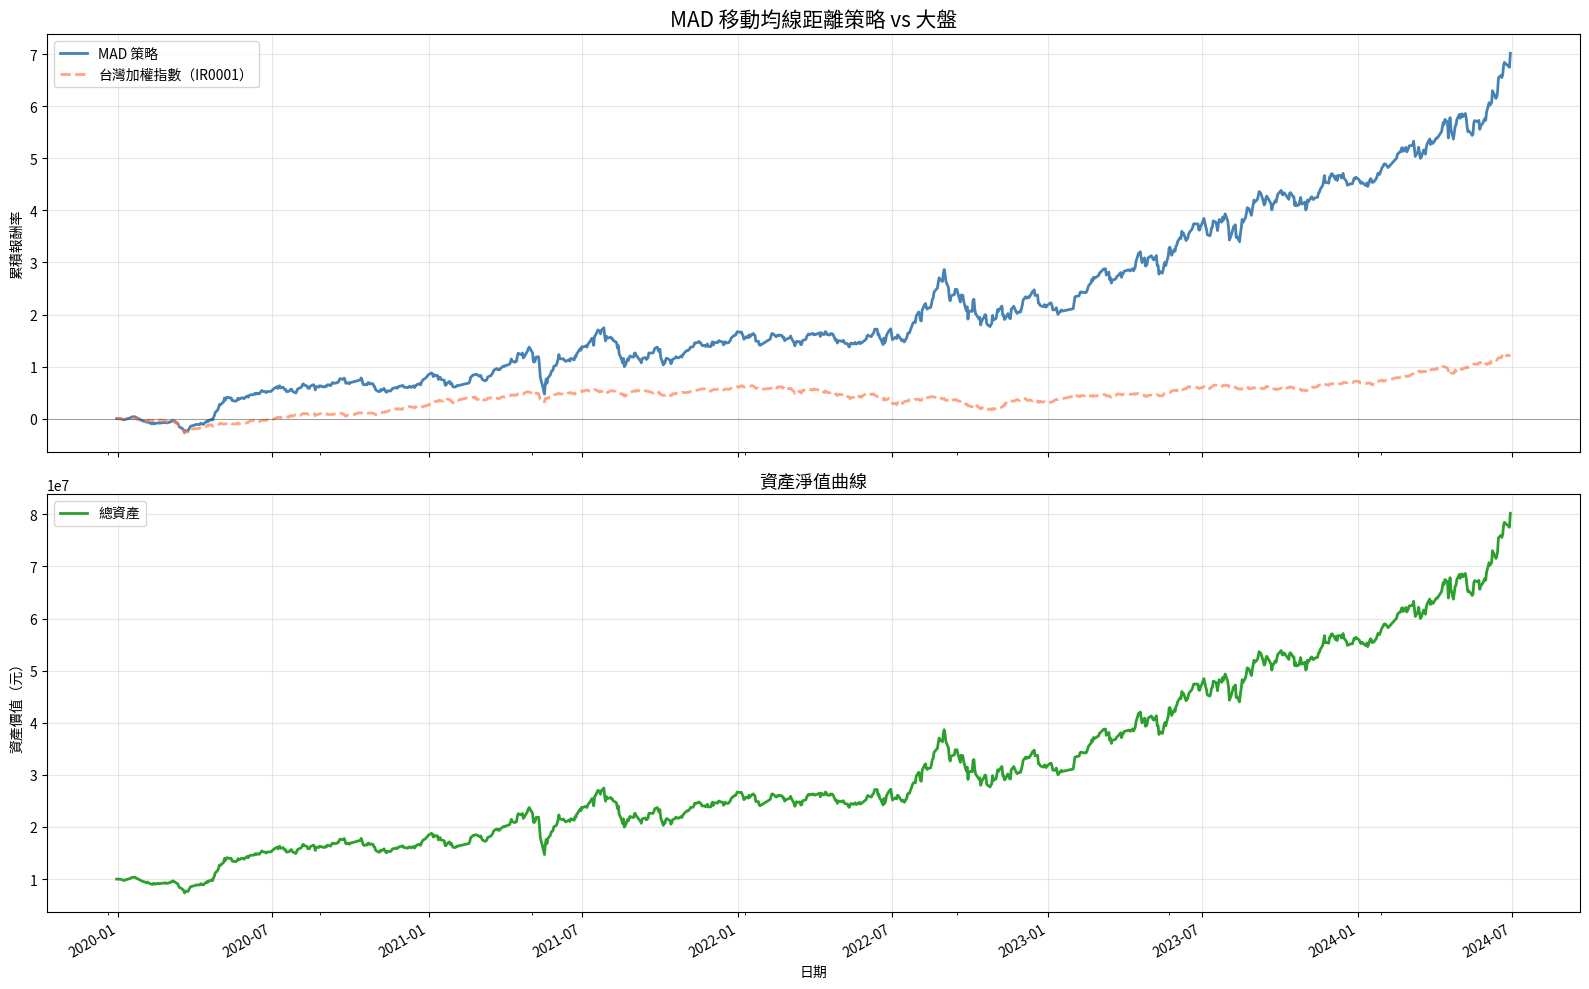


績效資料已儲存：mad_perf_2019-12-29_2024-06-30.csv

回測完成！


In [11]:
from zipline import run_algorithm

print("=" * 60)
print("開始回測 MAD 移動均線距離策略")
print(f"期間：{BACKTEST_START} ~ {END_DATE}")
print(f"均線：MA({MA_SHORT}) / MA({MA_LONG})，選股門檻：前 {int((1-TOP_DECILE)*100)}%")
print(f"初始資金：{CAPITAL_BASE:,.0f} 元")
print("=" * 60)

perf = run_algorithm(
    start        = pd.Timestamp(BACKTEST_START, tz='utc'),
    end          = pd.Timestamp(END_DATE,       tz='utc'),
    initialize   = initialize,
    handle_data  = handle_data,
    analyze      = analyze,
    bundle       = 'tquant',
    capital_base = CAPITAL_BASE
)

print("\n回測完成！")


## 9. 績效統計摘要與 Pyfolio 分析



------ 大盤績效指標 ------


Start date,2019-12-30
End date,2024-06-28
Total months,52
,Backtest
Annual return,20.268%
Cumulative returns,122.655%
Annual volatility,17.845%
Sharpe ratio,1.12
Calmar ratio,0.71
Stability,0.67
Max drawdown,-28.553%



------ MAD 策略完整分析 ------


Start date,2019-12-30
End date,2024-06-28
Total months,52
,Backtest
Annual return,61.608%
Cumulative returns,701.983%
Annual volatility,34.122%
Sharpe ratio,1.58
Calmar ratio,1.62
Stability,0.95
Max drawdown,-38.035%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,38.03,2021-04-29,2021-05-17,2021-06-30,43
1,29.24,2020-01-20,2020-03-19,2020-04-23,59
2,28.37,2022-08-31,2022-10-24,2023-03-07,122
3,27.21,2021-07-26,2021-08-19,2022-07-25,245
4,15.46,2020-10-13,2020-11-12,2020-12-29,56


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

Top 10 long positions of all time,max
sid,
1325,55.16%
2369,42.36%
3679,39.09%
1475,38.99%
3454,38.64%
1442,38.13%
6165,36.61%
4736,34.12%
2034,33.46%


Top 10 short positions of all time,max
sid,
1475,-69.21%
1418,-14.86%
1472,-4.76%
6655,-2.97%
3229,-0.50%
1454,-0.12%


Top 10 positions of all time,max
sid,
1475,69.21%
1325,55.16%
2369,42.36%
3679,39.09%
3454,38.64%
1442,38.13%
6165,36.61%
4736,34.12%
2034,33.46%


findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

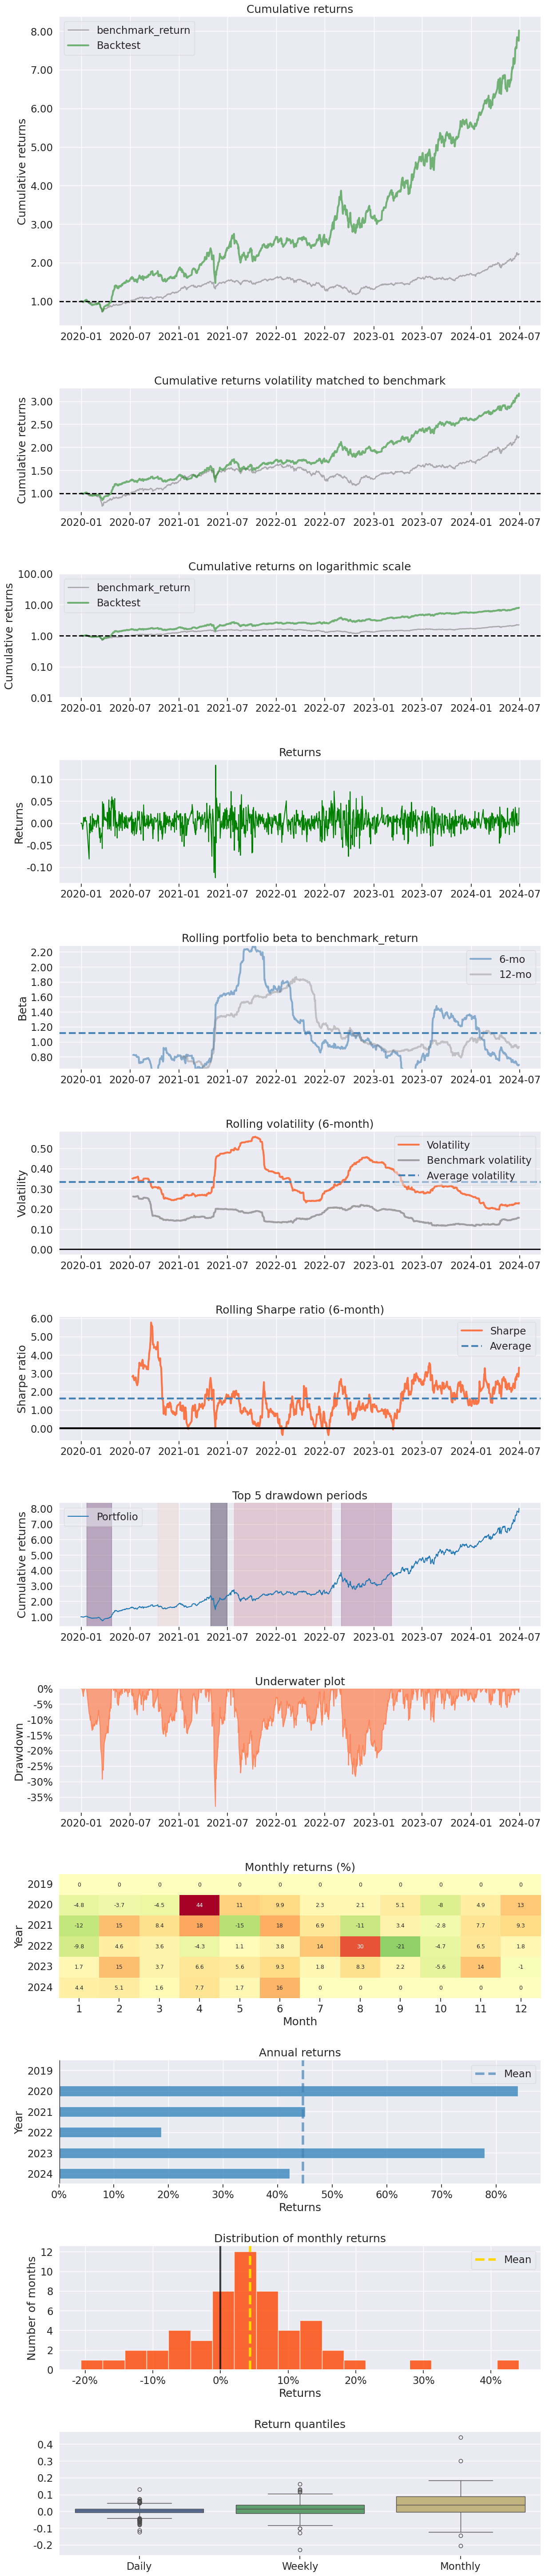

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

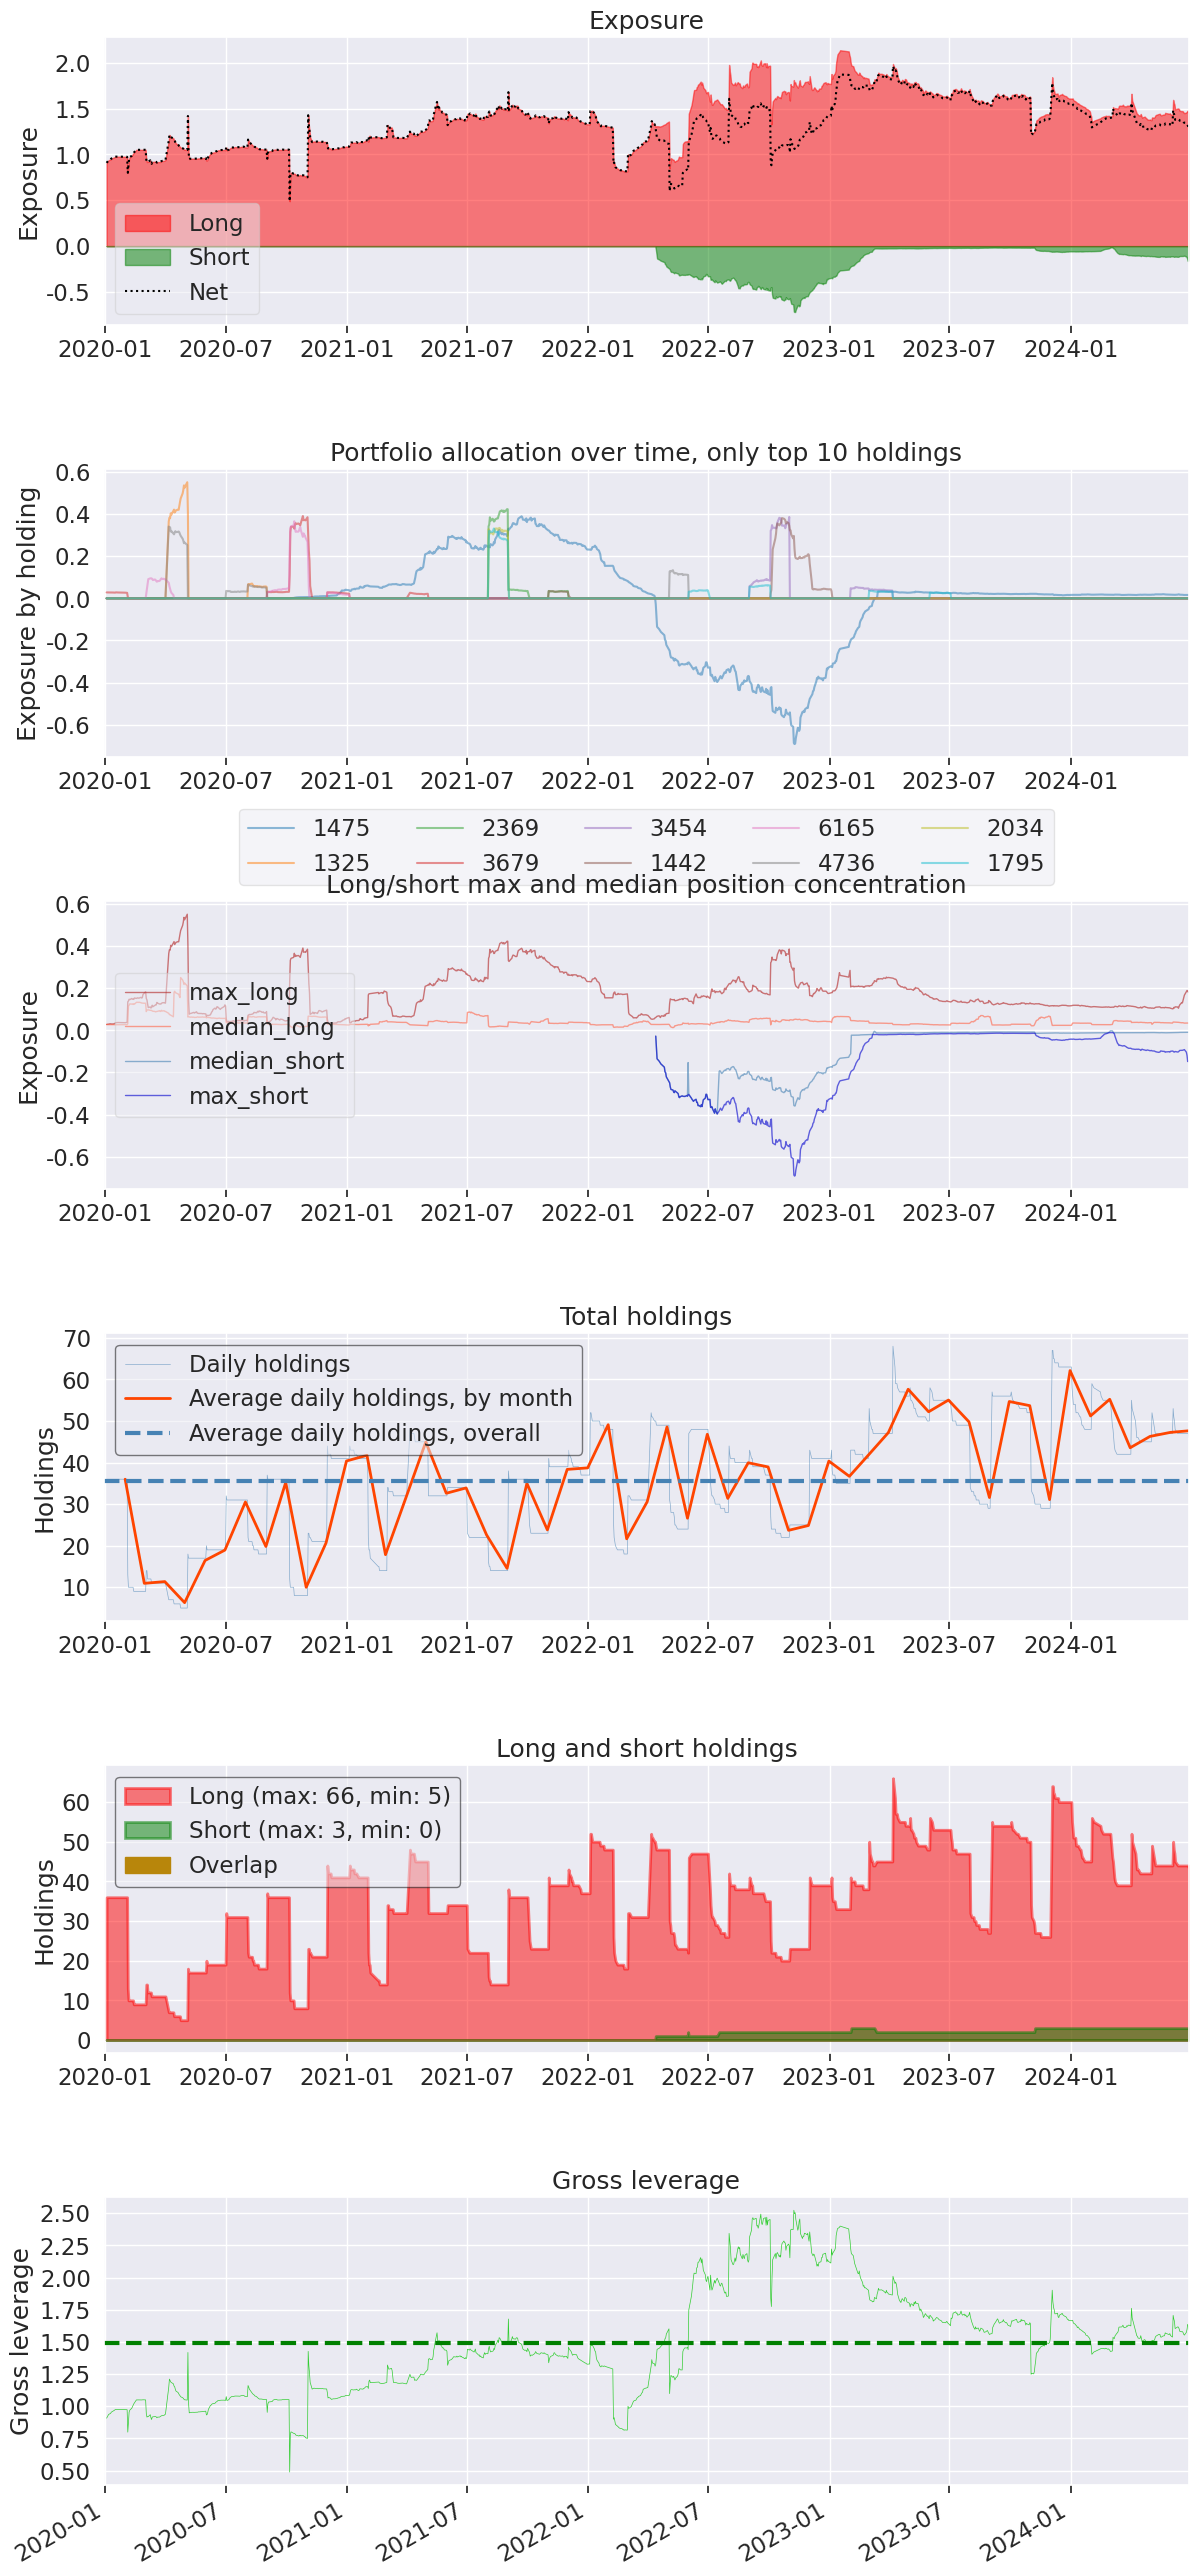

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

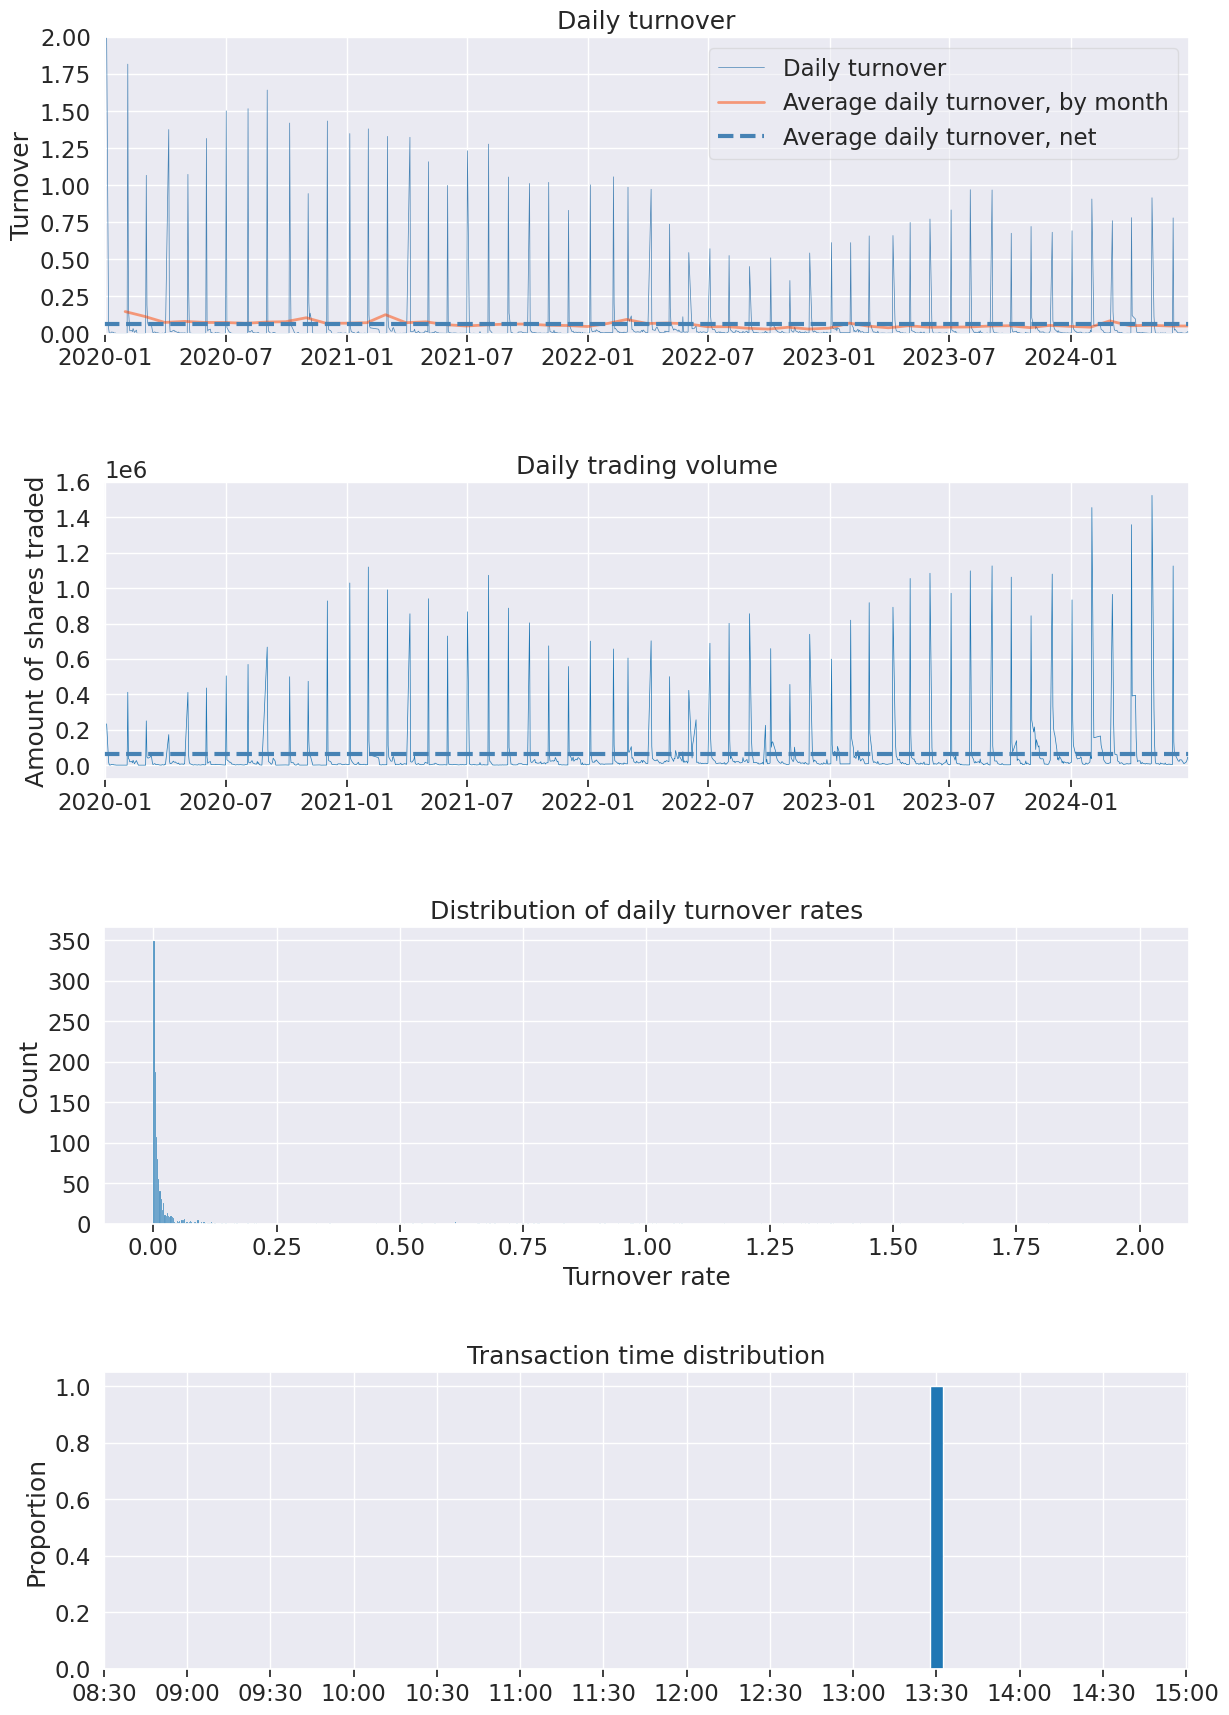

In [12]:
# ── Pyfolio 完整分析（含持倉、交易分析）─────────────────────────────────────
try:
    import pyfolio as pf
    from pyfolio.utils import extract_rets_pos_txn_from_zipline

    returns, positions, transactions = extract_rets_pos_txn_from_zipline(perf)
    benchmark_rets = perf.benchmark_return

    print("\n------ 大盤績效指標 ------")
    pf.show_perf_stats(benchmark_rets)

    print("\n------ MAD 策略完整分析 ------")
    pf.tears.create_full_tear_sheet(
        returns        = returns,
        positions      = positions,
        transactions   = transactions,
        benchmark_rets = benchmark_rets
    )

except ImportError:
    print("未安裝 pyfolio，略過詳細分析")
    print("若需完整報告，請執行: pip install pyfolio")
except Exception as e:
    print(f"Pyfolio 分析錯誤：{e}")


## 策略總結

### 核心特色

1. **純技術面選股**：只需收盤價，不依賴財報或籌碼資料，資料獲取成本極低
2. **行為財務學基礎**：利用投資人對長期均線的錨定偏誤捕捉動能溢酬
3. **橫截面排序**：每月與全市場比較，動態適應市況
4. **自動空倉機制**：熊市期間全市場 MRAT < 1 + σ 時自動空倉，降低回撤

### 選股邏輯流程

```
每月最後交易日收盤後
   ↓
計算全市場所有股票 MRAT = MA(21) / MA(200)
   ↓
計算橫截面 σ = std(全市場 MRAT)
   ↓
篩選：MRAT 前 10%  且  MRAT > 1 + σ
   ↓
次個交易日盤中等權重換倉
```

### 延伸優化方向

| 方向 | 說明 |
|------|------|
| 加入流動性篩選 | 排除日均成交量 < 500 萬元的股票 |
| 多空組合 | 做空 MRAT 後 10% 股票，提升 alpha 穩定性 |
| 調整均線週期 | 測試 MA(5)/MA(252) 或 MA(10)/MA(120) |
| 加入市場廣度過濾 | 全市場 MRAT 均值 < 1 時全部空倉 |
| 縮短再平衡週期 | 改為雙週或週度，提高敏感性 |

### 參考文獻

- Avramov, D., Kaplanski, G., & Subrahmanyam, A. (2021). Moving average distance as a predictor of equity returns. Review of Financial Economics, 39(2), 127-145. https://doi.org/10.1002/rfe.1118

- Jegadeesh, N., & Titman, S. (1993). Returns to buying winners and selling losers: Implications for stock market efficiency. The Journal of Finance, 48(1), 65-91. https://doi.org/10.1111/j.1540-6261.1993.tb04702.x

---

**免責聲明**：本策略僅供學術研究與教學用途，不構成投資建議。實際投資請審慎評估風險並諮詢專業顧問。
